# Visualizacion

In [12]:
import sys, os
sys.path.append(os.path.abspath(os.path.join("..", "src")))
os.chdir("..")

import pandas as pd
pd.set_option("display.max_columns", None)

from ingesta import CargarDatos
from eda import ProceEDA
from visualizacion import Visualizar

# Cargar el dataset procesado

In [13]:
cargador = CargarDatos()
df_crudo = cargador.cargar_raw_existente() if os.path.exists(cargador.ruta_raw) \
    else cargador.ejecutar_pipeline_ingesta()

eda = ProceEDA(df_crudo)
eda.limpieza_datos()
df = eda.generar_columnas_derivadas()

resultados_equipo = eda.resultados_por_equipo()
matriz_corr = eda.matriz_correlacion()
df_anfitrion = eda.anfitrion_gana_mas()

df.head()

Partidos descargados en total: 49505
Partidos de Copa Mundial encontrados: 1062
Los datos son válidos.
Archivo guardado en data/raw/partidos-mundial.csv
Limpieza completada: 1062 -> 1062 filas
Columnas agregadas: anio, total_goles, diferencia_goles, ganador


,id_partido,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,anio,total_goles,diferencia_goles,ganador
0,1,1930-07-13,Belgium,United States,0,3,FIFA World Cup,Montevideo,Uruguay,True,1930,3,3,Visitante
1,2,1930-07-13,France,Mexico,4,1,FIFA World Cup,Montevideo,Uruguay,True,1930,5,3,Local
2,3,1930-07-14,Brazil,Yugoslavia,1,2,FIFA World Cup,Montevideo,Uruguay,True,1930,3,1,Visitante
3,4,1930-07-14,Peru,Romania,1,3,FIFA World Cup,Montevideo,Uruguay,True,1930,4,2,Visitante
4,5,1930-07-15,Argentina,France,1,0,FIFA World Cup,Montevideo,Uruguay,True,1930,1,1,Local


In [14]:
visual = Visualizar(df)

# ¿En que mundial se metieron mas goles por partido?

Gráfico guardado en data/processed/graficos/01_goles_promedio_por_edicion.png


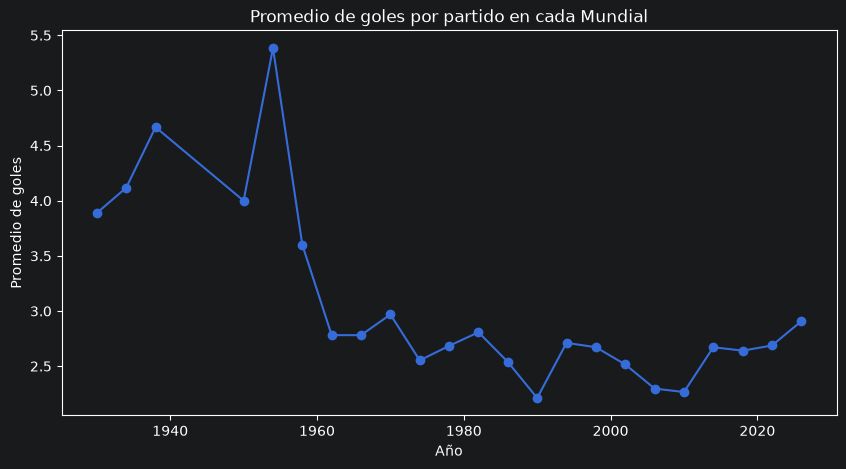

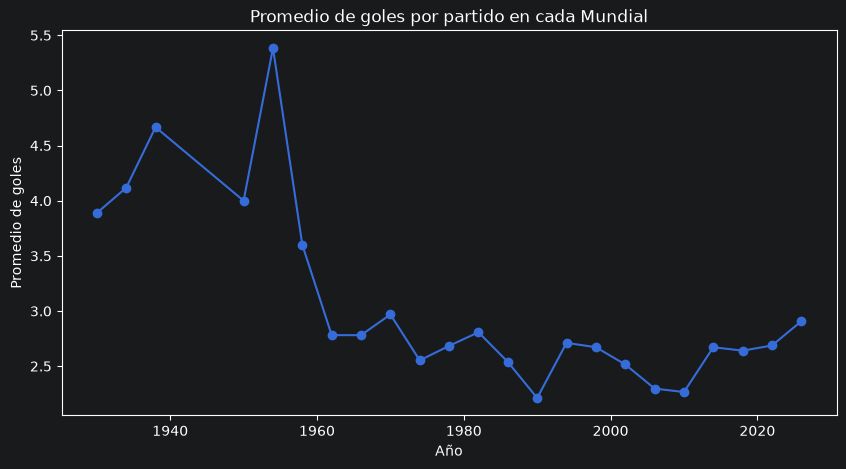

In [15]:
visual.goles_promedio_por_edicion()

# ¿El pais sede gana mas?

Gráfico guardado en data/processed/graficos/02_distribucion_resultados.png


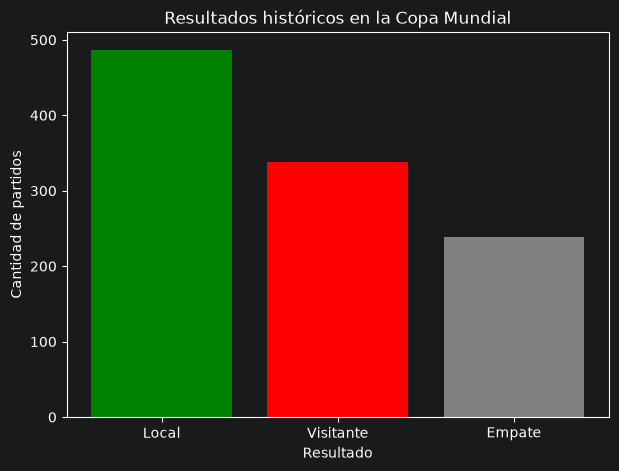

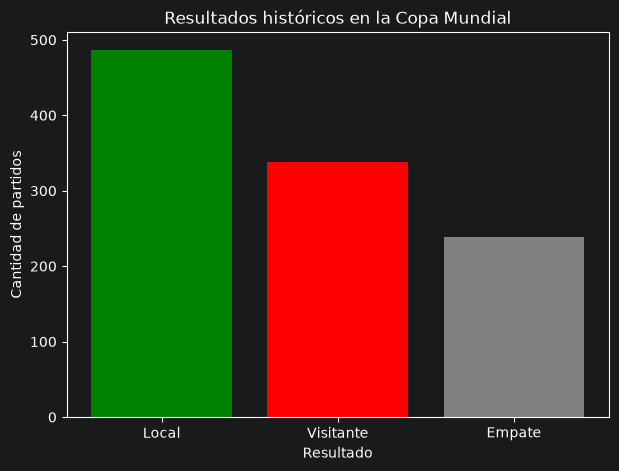

In [16]:
visual.ventaja_local_barras()

# ¿Que seleccion tiene la mejor diferencia de goles?

Gráfico guardado en data/processed/graficos/03_top_diferencia_gol.png


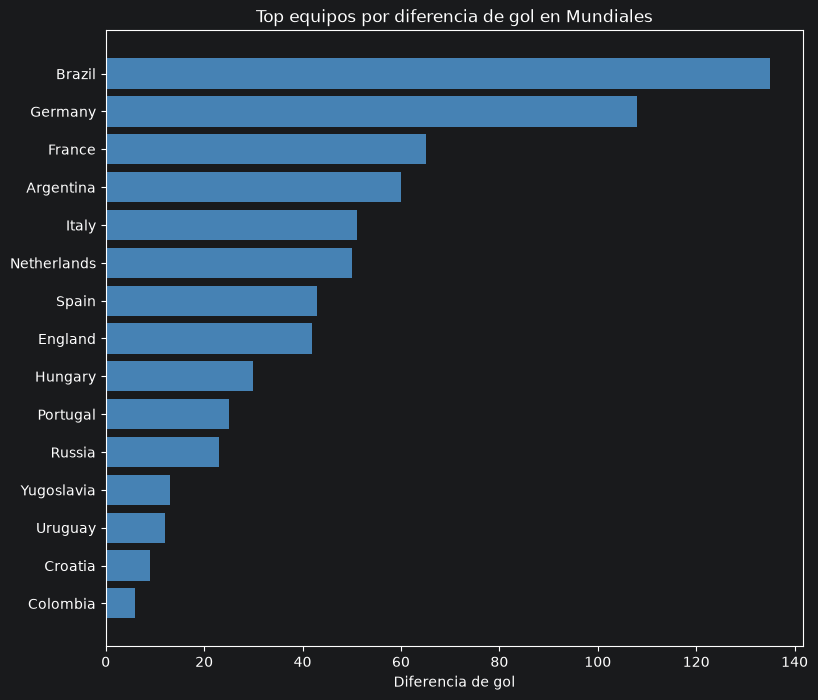

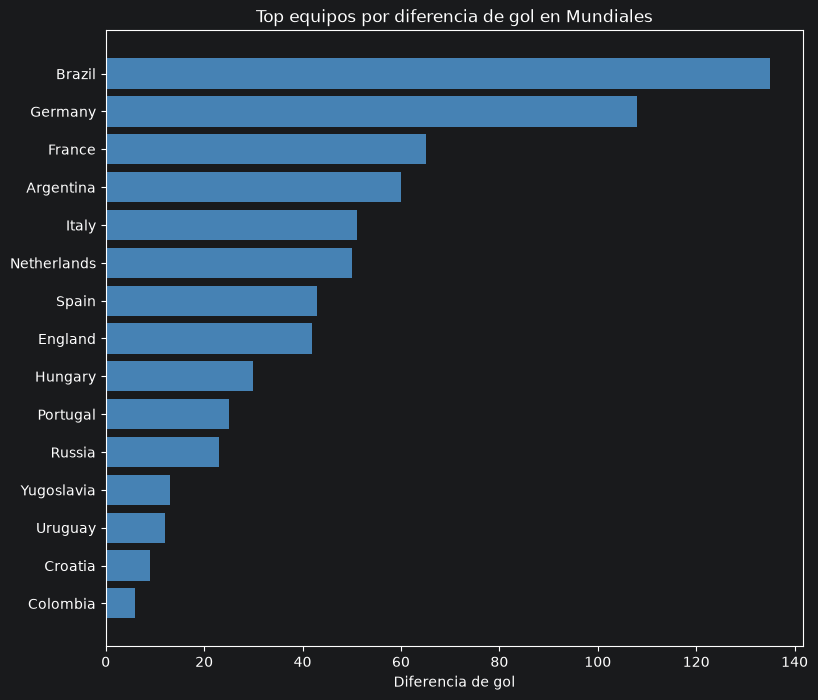

In [17]:
visual.top_diferencia_gol(resultados_equipo, top=15)

# Matriz de correlacion

Gráfico guardado en data/processed/graficos/04_heatmap_correlacion.png


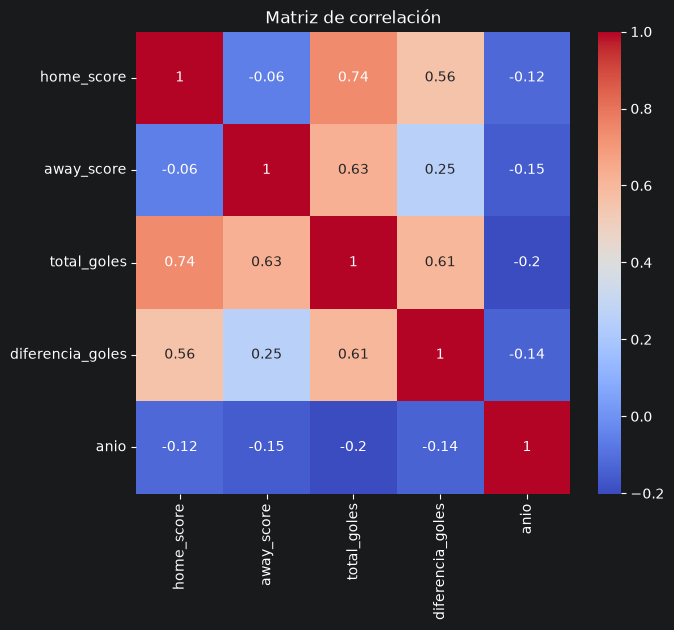

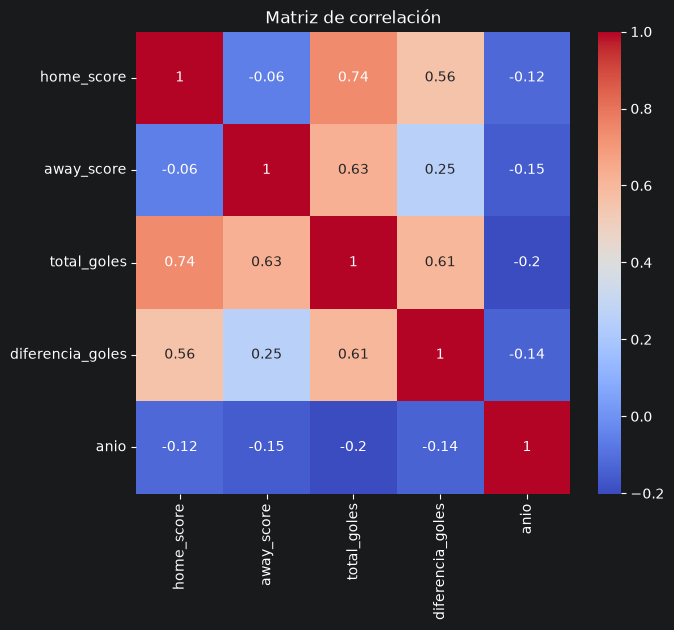

In [18]:
visual.heatmap_correlacion(matriz_corr)

# Distribucion de goles por partido

Gráfico guardado en data/processed/graficos/05_histograma_goles_totales.png


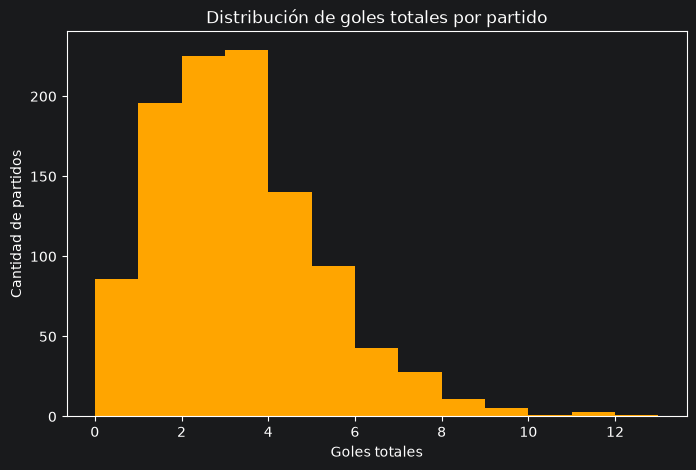

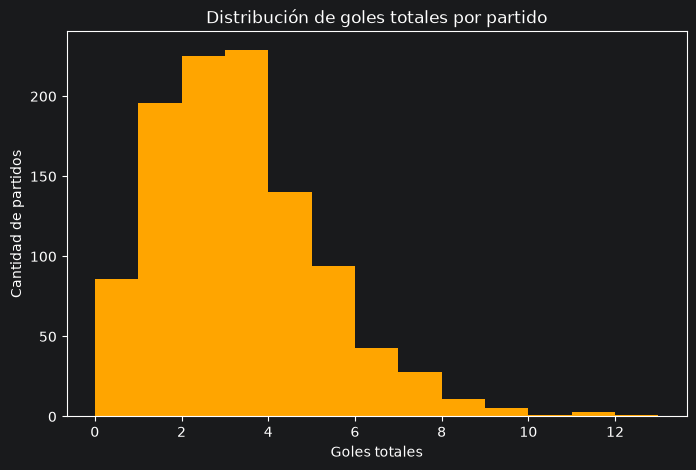

In [19]:
visual.histograma_goles_totales()

# Desempeño del pais anfitrion de cada edicion del mundial

Gráfico guardado en data/processed/graficos/07_desempeno_anfitrion.png


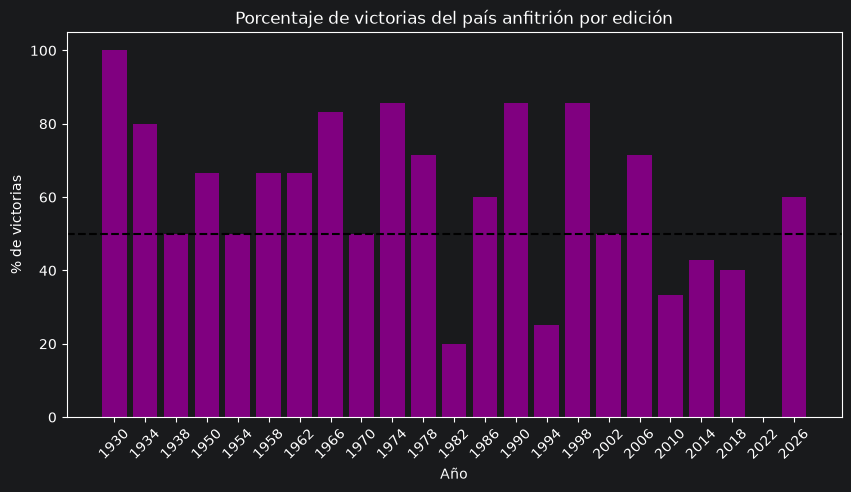

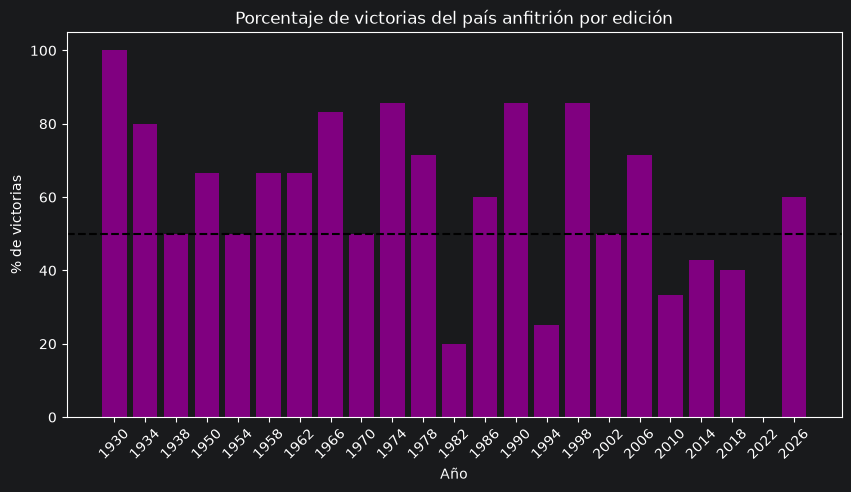

In [24]:
visual.desempeno_anfitrion(df_anfitrion)